# Posterior Associations - General Analysis

This notebook analyzes posterior associations from clustering results.

For merger history analysis, see the separate `merger_histories.ipynb` notebook.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, '..')

from backend.io import load_hdbscan_clusters_from_hdf5

## Configuration

Specify the path to the posterior association catalog HDF5 file below.

In [2]:
# ============================================================
# CONFIGURATION - Edit these parameters
# ============================================================

# Path to the posterior association catalog (HDF5 file)
CATALOG_PATH = "../output/dbscan_clusters_eps_2.75_ms_10.h5"

# Quality selection: "Raw", "Fiducial", or "Strict"
#   Raw:      No cuts (all clusters)
#   Fiducial: ambiguity_rate <= 0.05, n_members >= 20
#   Strict:   Fiducial + sigma_R <= 2.5 Mpc, sigma_log_M <= 0.25 dex
QUALITY_SELECTION = "Fiducial"

# Plotting style
try:
    from pymanticore.analysis.matplotlib import get_mplstyle_path
    mnras_style = "mnras"
    USE_MNRAS_STYLE = True
except ImportError:
    USE_MNRAS_STYLE = False
    print("pymanticore not found, using default matplotlib style")

# ============================================================

print(f"Catalog: {CATALOG_PATH}")
print(f"Quality selection: {QUALITY_SELECTION}")

pymanticore not found, using default matplotlib style
Catalog: ../output/dbscan_clusters_eps_2.75_ms_10.h5
Quality selection: Fiducial


## Load Data

Load cluster data from the HDF5 catalog and apply quality selection cuts.

In [3]:
# Load clusters using the backend IO function
clusters_raw, assignments, metadata = load_hdbscan_clusters_from_hdf5(
    os.path.dirname(CATALOG_PATH),
    os.path.basename(CATALOG_PATH),
    min_existence_prob=0.0,
    load_members=True
)

print(f"Loaded {len(clusters_raw)} clusters (raw)")

# Define quality selection criteria
SELECTION_CUTS = {
    'Raw': {},  # No cuts
    'Fiducial': {
        'ambiguity_rate': (None, 0.05),
        'n_members': (20, None),
    },
    'Strict': {
        'ambiguity_rate': (None, 0.05),
        'n_members': (20, None),
        'sigma_R': (None, 2.5),
        'sigma_log_M': (None, 0.25),
    },
}

def apply_quality_cuts(clusters_list, selection_name):
    """Apply quality cuts to filter clusters."""
    if selection_name not in SELECTION_CUTS:
        raise ValueError(f"Unknown selection: {selection_name}. Choose from {list(SELECTION_CUTS.keys())}")
    
    cuts = SELECTION_CUTS[selection_name]
    if not cuts:
        return clusters_list  # Raw - no filtering
    
    filtered = []
    for c in clusters_list:
        # Extract values for comparison
        values = {
            'ambiguity_rate': c.get('ambiguity_rate', 0),
            'n_members': c.get('n_members', 0),
            'sigma_R': np.linalg.norm(c.get('position_std', [0, 0, 0])),
            'sigma_log_M': c.get('log10_m200_mass_std', 0),
        }
        
        # Check all cuts
        passes = True
        for key, (lo, hi) in cuts.items():
            val = values.get(key, 0)
            if lo is not None and val < lo:
                passes = False
                break
            if hi is not None and val > hi:
                passes = False
                break
        
        if passes:
            filtered.append(c)
    
    return filtered

# Apply the selected quality cuts
clusters = apply_quality_cuts(clusters_raw, QUALITY_SELECTION)
clusters_available = len(clusters) > 0

print(f"After '{QUALITY_SELECTION}' cuts: {len(clusters)} clusters ({100*len(clusters)/len(clusters_raw):.1f}%)")

if clusters_available:
    print(f"Cluster size range: {min(c['n_members'] for c in clusters)} - {max(c['n_members'] for c in clusters)}")
    print(f"Mass range: {min(c['mean_m200_mass'] for c in clusters):.2e} - {max(c['mean_m200_mass'] for c in clusters):.2e} Msol")


Loaded HDBSCAN results from ../output/dbscan_clusters_eps_2.75_ms_10.h5
  Format version: 2
  Clusters loaded: 1210
  Total halos: 361800
Loaded 1210 clusters (raw)
After 'Fiducial' cuts: 434 clusters (35.9%)
Cluster size range: 20 - 80
Mass range: 8.62e+13 - 2.68e+15 Msol


## Plot 1: Example Halo Groupings

Shows 2D projections of halo members for selected clusters, demonstrating the spatial grouping of halos within each association.

In [4]:
def plot_multi_cluster_diagnostic(cluster_ids, window_size=15.0):
    if not clusters_available or len(clusters) == 0:
        print("No clusters available for diagnostic plot")
        return
    
    if len(cluster_ids) != 2:
        print("Function requires exactly 2 cluster IDs")
        return
    
    # Find target clusters
    target_clusters = []
    for cluster_id in cluster_ids:
        target_cluster = None
        for cluster in clusters:
            if cluster['cluster_id'] == cluster_id:
                target_cluster = cluster
                break
        if target_cluster is None:
            print(f"Cluster ID {cluster_id} not found")
            return
        target_clusters.append(target_cluster)
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()
    
    with style_context:
        fig, axes = plt.subplots(3, 2, figsize=(3.5, 5))
        
        projections = [
            (0, 1, 'X', 'Y'),
            (0, 2, 'X', 'Z'), 
            (1, 2, 'Y', 'Z')
        ]
        
        symbols = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
        
        # Collect all unique cluster IDs across both target clusters
        all_unique_cluster_ids = set()
        for target_cluster in target_clusters:
            target_cluster_center = target_cluster['center_xyz']
            
            # Find clusters whose centroids are within the window
            for cluster in clusters:
                cluster_center = cluster['center_xyz']
                distance_to_target = np.linalg.norm(cluster_center - target_cluster_center)
                if distance_to_target <= window_size:
                    all_unique_cluster_ids.add(cluster['cluster_id'])
        
        # Create global color and symbol map for all unique cluster IDs
        all_unique_cluster_ids = sorted(list(all_unique_cluster_ids))
        colors = plt.cm.tab10(np.linspace(0, 1, len(all_unique_cluster_ids)))
        global_color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(all_unique_cluster_ids)}
        global_symbol_map = {cluster_id: symbols[i % len(symbols)] for i, cluster_id in enumerate(all_unique_cluster_ids)}
        
        for proj_idx, (dim1, dim2, label1, label2) in enumerate(projections):
            for cluster_idx, target_cluster in enumerate(target_clusters):
                target_cluster_center = target_cluster['center_xyz']
                target_cluster_id = target_cluster['cluster_id']
                
                ax = axes[proj_idx, cluster_idx]
                
                # Find clusters whose centroids are within the window
                clusters_in_window = []
                for cluster in clusters:
                    cluster_center = cluster['center_xyz']
                    distance_to_target = np.linalg.norm(cluster_center - target_cluster_center)
                    if distance_to_target <= window_size:
                        clusters_in_window.append(cluster)
                
                # Only plot members from clusters whose centroids are in the window
                nearby_positions = []
                nearby_cluster_labels = []
                
                for cluster in clusters_in_window:
                    # Try different position keys depending on format
                    if 'member_data' in cluster:
                        if 'positions' in cluster['member_data']:
                            positions = cluster['member_data']['positions']
                        elif 'BoundSubhalo/CentreOfMass' in cluster['member_data']:
                            positions = cluster['member_data']['BoundSubhalo/CentreOfMass']
                        else:
                            # Skip if no position data
                            continue
                    else:
                        continue
                    
                    cluster_id_val = cluster['cluster_id']
                    nearby_positions.extend(positions)
                    nearby_cluster_labels.extend([cluster_id_val] * len(positions))
                
                nearby_positions = np.array(nearby_positions)
                nearby_cluster_labels = np.array(nearby_cluster_labels)
                
                # Calculate optimized axis limits for this subplot
                if len(nearby_positions) > 0:
                    min_pos = np.min(nearby_positions, axis=0)
                    max_pos = np.max(nearby_positions, axis=0)
                    ranges = max_pos - min_pos
                    centers = (min_pos + max_pos) / 2
                    max_range = np.max(ranges)
                    padding = max_range * 0.05
                else:
                    centers = target_cluster_center
                    max_range = 10.0
                    padding = 0.5
                
                unique_labels = np.unique(nearby_cluster_labels)
                
                legend_handles = []
                
                # Offset for centering (adjust if needed based on your data)
                offset = 500
                
                for label in unique_labels:
                    mask = nearby_cluster_labels == label
                    color = global_color_map[label]
                    symbol = global_symbol_map[label]
                    scatter = ax.scatter(nearby_positions[mask, dim1] - offset, 
                                        nearby_positions[mask, dim2] - offset, 
                                        c=[color], s=10, alpha=0.6, marker=symbol, 
                                        edgecolor="black", lw=0.2)
                    
                    legend_handles.append(plt.Line2D([0], [0], marker=symbol, color='w', 
                                                     markerfacecolor=color, markersize=8, 
                                                     label=f'Association {label}', alpha=0.6))
                
                # Plot cluster centroids and annotations
                for cluster in clusters_in_window:
                    cluster_center = cluster['center_xyz'] - offset
                    cluster_id_val = cluster['cluster_id']
                    color = global_color_map[cluster_id_val]
                    
                    # Mark centroid
                    ax.scatter(cluster_center[dim1], cluster_center[dim2], 
                              c='red', s=100, marker='*', edgecolors='black', linewidth=0.5)
                    
                    # Add position std circle around centroid
                    position_std = np.linalg.norm(cluster['position_std'])
                    circle = plt.Circle((cluster_center[dim1], cluster_center[dim2]), 
                                       position_std, fill=False, color=color, 
                                       linestyle='-', linewidth=1, alpha=0.7)
                    ax.add_patch(circle)

                ax.set_xlabel(f'{label1} (Mpc)')
                ax.set_ylabel(f'{label2} (Mpc)')
                
                ax.set_aspect('equal')
                
                # Set optimized square axis limits
                center_2d = centers[[dim1, dim2]]
                half_range = max_range / 2 + padding
                ax.set_xlim((center_2d[0] - offset) - half_range, (center_2d[0] - offset) + half_range)
                ax.set_ylim((center_2d[1] - offset) - half_range, (center_2d[1] - offset) + half_range)
                
                # Add legend only to bottom row
                if proj_idx == 2 and legend_handles:
                    ax.legend(handles=legend_handles, loc="upper left", fontsize=6)
        
        plt.tight_layout(pad=0.1)
        plt.subplots_adjust(hspace=0.3, wspace=0.3)
        plt.savefig("./plots/example_halo_groupings.pdf")
        plt.show()

Top 20 cluster IDs by size: [0, 2, 4, 5, 6, 12, 14, 16, 17, 18, 19, 20, 22, 25, 28, 30, 31, 37, 43, 44]

Plotting clusters: [17, 44]


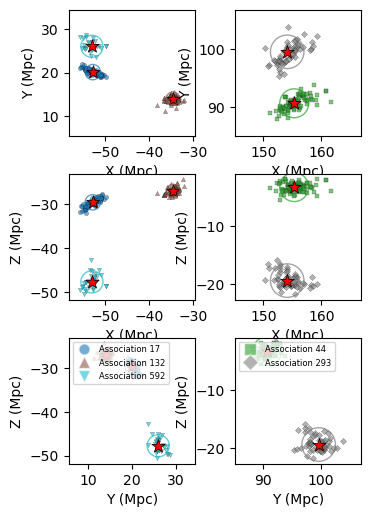

In [5]:
#### Select two cluster IDs to plot (modify these based on your data)
# Choose clusters with interesting groupings
if clusters_available:
    # Get cluster IDs sorted by size
    sorted_clusters = sorted(clusters, key=lambda c: c['n_members'], reverse=True)
    available_ids = [c['cluster_id'] for c in sorted_clusters[:20]]
    print(f"Top 20 cluster IDs by size: {available_ids}")
    
    # Default to first two large clusters
    cluster_ids_to_plot = [17,44] # available_ids[:2]
    print(f"\nPlotting clusters: {cluster_ids_to_plot}")
    
    plot_multi_cluster_diagnostic(cluster_ids_to_plot, window_size=20)

## Plot 2: Position Standard Deviation and Axis Ratio vs Mass

Shows how the spatial scatter (position_std) and shape (axis ratio b/a) of associations vary with their mean mass, binned by association size.

In [6]:
def plot_position_std_and_axis_ratio_vs_mass(size_bin_edges):
    if not clusters_available or len(clusters) == 0:
        print("No clusters available")
        return
    
    cluster_masses = np.array([cluster['mean_m200_mass'] for cluster in clusters])
    position_stds = np.array([np.linalg.norm(cluster['position_std']) for cluster in clusters])
    cluster_sizes = np.array([cluster['n_members'] for cluster in clusters])
    axis_ratio_ba = np.array([cluster.get('axis_ratio_ba', np.nan) for cluster in clusters])
    
    # Create masks for size bins using bin edges
    masks = []
    labels = []
    for i in range(len(size_bin_edges) - 1):
        mask = (cluster_sizes >= size_bin_edges[i]) & (cluster_sizes < size_bin_edges[i+1])
        labels.append(f'{size_bin_edges[i]}-{size_bin_edges[i+1]}')
        masks.append(mask)
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(masks)))
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()

    with style_context:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.15, 3.5), sharex=True)
        
        # Create log-spaced mass bins
        mass_bins = np.logspace(np.log10(cluster_masses.min()), np.log10(cluster_masses.max()), 15)
        
        # Top panel: Position STD
        for i, (mask, label, color) in enumerate(zip(masks, labels, colors)):
            if np.sum(mask) == 0:
                continue
                
            masses_subset = cluster_masses[mask]
            stds_subset = position_stds[mask]
            
            # Bin the data
            bin_indices = np.digitize(masses_subset, mass_bins)
            
            medians = []
            p25 = []
            p75 = []
            bin_centers = []
            
            for j in range(1, len(mass_bins)):
                bin_mask = bin_indices == j
                if np.sum(bin_mask) >= 3:  # Need at least 3 points for statistics
                    bin_stds = stds_subset[bin_mask]
                    medians.append(np.median(bin_stds))
                    p25.append(np.percentile(bin_stds, 25))
                    p75.append(np.percentile(bin_stds, 75))
                    bin_centers.append(np.sqrt(mass_bins[j-1] * mass_bins[j]))
            
            if len(medians) > 0:
                bin_centers = np.array(bin_centers)
                medians = np.array(medians)
                p25 = np.array(p25)
                p75 = np.array(p75)
                
                ax1.plot(bin_centers, medians, '-o', color=color, label=label, linewidth=1, markersize=3)
                ax1.fill_between(bin_centers, p25, p75, color=color, alpha=0.2, lw=None)
        
        ax1.set_ylabel("Association positional\n" + r"standard deviation $\sigma_{R}$ [Mpc]")
        ax1.set_xscale('log')
        ax1.legend(title=r"Association $N_{\mathrm{members}}$")
        
        # Bottom panel: Axis Ratio b/a
        for i, (mask, label, color) in enumerate(zip(masks, labels, colors)):
            if np.sum(mask) == 0:
                continue
                
            masses_subset = cluster_masses[mask]
            axis_ratio_subset = axis_ratio_ba[mask]
            
            # Filter out NaN values
            finite_mask = np.isfinite(axis_ratio_subset)
            if np.sum(finite_mask) == 0:
                continue
                
            masses_subset = masses_subset[finite_mask]
            axis_ratio_subset = axis_ratio_subset[finite_mask]
            
            # Bin the data
            bin_indices = np.digitize(masses_subset, mass_bins)
            
            medians = []
            p25 = []
            p75 = []
            bin_centers = []
            
            for j in range(1, len(mass_bins)):
                bin_mask = bin_indices == j
                if np.sum(bin_mask) >= 3:  # Need at least 3 points for statistics
                    bin_ratios = axis_ratio_subset[bin_mask]
                    medians.append(np.median(bin_ratios))
                    p25.append(np.percentile(bin_ratios, 25))
                    p75.append(np.percentile(bin_ratios, 75))
                    bin_centers.append(np.sqrt(mass_bins[j-1] * mass_bins[j]))
            
            if len(medians) > 0:
                bin_centers = np.array(bin_centers)
                medians = np.array(medians)
                p25 = np.array(p25)
                p75 = np.array(p75)
                
                ax2.plot(bin_centers, medians, '-o', color=color, linewidth=1, markersize=3)
                ax2.fill_between(bin_centers, p25, p75, color=color, alpha=0.2, lw=None)
        
        ax2.set_xlabel(r'Association mean mass $\langle M_{\mathrm{200}} \rangle$ [M$_{\odot}$]')
        ax2.set_ylabel(r'Association axis Ratio $b/a$')
        ax2.set_xscale('log')
        
        plt.tight_layout(pad=0.1)
        plt.savefig("./plots/position_std_and_axis_ratio_vs_mass.pdf")
        plt.show()

Cluster size range: 20 - 80
Cluster size quartiles: [25. 34. 47.]

Using size bins: [20, 40, 60, 80]


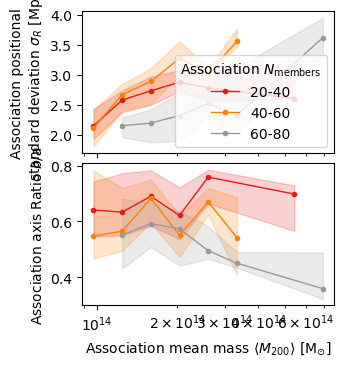

In [7]:
# Define size bins and create plot
if clusters_available:
    # Check the range of cluster sizes to set appropriate bins
    sizes = [c['n_members'] for c in clusters]
    print(f"Cluster size range: {min(sizes)} - {max(sizes)}")
    print(f"Cluster size quartiles: {np.percentile(sizes, [25, 50, 75])}")
    
    # Define bin edges (modify based on your data)
    size_bin_edges = [20, 40, 60, 80]
    print(f"\nUsing size bins: {size_bin_edges}")
    
    plot_position_std_and_axis_ratio_vs_mass(size_bin_edges)

## Plot 3: Posterior Positions

Shows all association member positions in XY projection and on-sky (Mollweide) projection.

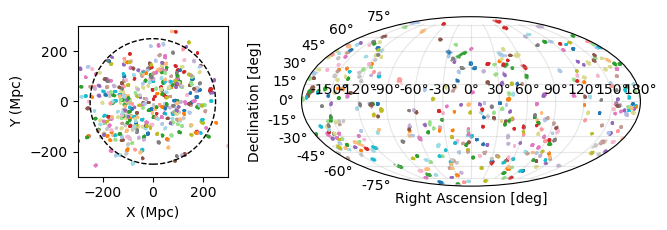

In [8]:
import random

def plot_posterior_positions():
    if not clusters_available or len(clusters) == 0:
        print("No clusters available")
        return
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()
    
    with style_context:
        fig = plt.figure(figsize=(6.5, 3.0))
        gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.25])

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1], projection='mollweide')

        # Assign random colors to each cluster
        tab20_colors = plt.cm.tab20(np.linspace(0, 1, 20))
        random.seed(42)
        assigned_colors = random.choices(tab20_colors, k=len(clusters))

        for i, cluster in enumerate(clusters):
            color = assigned_colors[i]
            
            # Get positions - try different keys depending on format
            if 'member_data' not in cluster:
                continue
            
            member_data = cluster['member_data']
            
            # Get XYZ positions
            if 'positions' in member_data:
                positions = member_data['positions']
            elif 'BoundSubhalo/CentreOfMass' in member_data:
                positions = member_data['BoundSubhalo/CentreOfMass']
            else:
                continue
            
            # Plot XY projection (offset by 500 to center on observer)
            ax1.scatter(positions[:, 0] - 500, positions[:, 1] - 500, 
                       c=[color], s=1, alpha=0.7, marker=".", rasterized=True)

            # Get RA/Dec for Mollweide
            if 'ra' in member_data and 'dec' in member_data:
                ra = np.asarray(member_data['ra'])
                dec = np.asarray(member_data['dec'])
            else:
                # Compute from positions if not available
                observer = np.array([500, 500, 500])
                rel_pos = positions - observer
                dist = np.linalg.norm(rel_pos, axis=1)
                ra = np.degrees(np.arctan2(rel_pos[:, 1], rel_pos[:, 0]))
                dec = np.degrees(np.arcsin(rel_pos[:, 2] / dist))
            
            # Mollweide expects longitude (ra) in [-pi, pi] and latitude (dec) in radians
            ra_wrapped = np.where(ra > 180, ra - 360, ra)  # wrap to [-180, 180]
            ra_rad = np.radians(ra_wrapped)
            dec_rad = np.radians(dec)
            ax2.scatter(ra_rad, dec_rad, c=[color], s=1, alpha=0.7, marker=".", rasterized=True)

        # 2D plot formatting
        ax1.set_xlabel('X (Mpc)')
        ax1.set_ylabel('Y (Mpc)')
        ax1.set_ylim(-300, 300)
        ax1.set_xlim(-300, 300)
        circle = plt.Circle((0, 0), 250, fill=False, color='black', linestyle='--', linewidth=1)
        ax1.add_patch(circle)
        ax1.set_aspect('equal')

        # Mollweide formatting
        ax2.grid(True, alpha=0.3)
        tick_labels = np.arange(-150, 181, 30)
        ax2.set_xticks(np.radians(tick_labels))
        ax2.set_xticklabels([f"{tl}°" for tl in tick_labels])
        ax2.set_xlabel('Right Ascension [deg]')
        ax2.set_ylabel('Declination [deg]')

        plt.tight_layout(pad=0.1)
        plt.subplots_adjust(wspace=0.3)
        plt.savefig("./plots/posterior_positions.pdf")
        plt.show()

# Create the plot
plot_posterior_positions()

## Plot 4: Mean Distances and Mass Distribution

Two-panel plot showing:
- Top: Histogram of mean distances from observer with expected R² scaling
- Bottom: Halo mass distribution

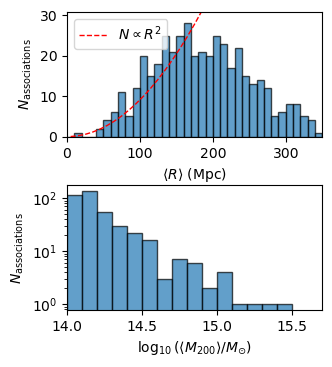

Distance statistics:
  Mean: 186.0 Mpc
  Median: 181.3 Mpc
  Min/Max: 19.3 / 377.2 Mpc

Mass statistics:
  Mean log10(M200): 14.21
  Median log10(M200): 14.15
  Min/Max log10(M200): 13.94 / 15.43


In [15]:
def plot_distances_and_mass():
    if not clusters_available or len(clusters) == 0:
        print("No clusters available")
        return
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()
    
    # Calculate mean distance for each cluster
    observer = np.array([500, 500, 500])
    mean_distances = []
    masses = []
    
    for cluster in clusters:
        # Get mass
        masses.append(cluster['mean_m200_mass'])
        
        if 'member_data' not in cluster:
            # Fall back to cluster center for distance
            dist = np.linalg.norm(cluster['center_xyz'] - observer)
            mean_distances.append(dist)
            continue
        
        member_data = cluster['member_data']
        
        # Try to get distance directly, or compute from positions
        if 'dist' in member_data:
            dist = np.mean(member_data['dist'])
        elif 'positions' in member_data:
            positions = member_data['positions']
            dists = np.linalg.norm(positions - observer, axis=1)
            dist = np.mean(dists)
        elif 'BoundSubhalo/CentreOfMass' in member_data:
            positions = member_data['BoundSubhalo/CentreOfMass']
            dists = np.linalg.norm(positions - observer, axis=1)
            dist = np.mean(dists)
        else:
            # Fall back to cluster center
            dist = np.linalg.norm(cluster['center_xyz'] - observer)
        
        mean_distances.append(dist)
    
    mean_distances = np.array(mean_distances)
    masses = np.array(masses)
    log_masses = np.log10(masses)
    
    with style_context:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.15, 3.5))
        
        # Top panel: Distance histogram
        n, bins, patches = ax1.hist(mean_distances, bins=np.arange(0, 510, 10),
                                    alpha=0.7, edgecolor='black')
        
        # Add R² scaling line (expected for uniform distribution in 3D)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        r_squared_line = bin_centers**2
        scaling_factor = 1./1100  # Adjust this to match your data
        r_squared_line *= scaling_factor
        ax1.plot(bin_centers, r_squared_line, 'r--', linewidth=1, label=r'$N \propto R^2$')
        
        ax1.set_xlabel(r'$\langle R \rangle$ (Mpc)')
        ax1.set_ylabel(r'$N_{\mathrm{associations}}$')
        ax1.set_ylim(0, 1.1 * np.max(n))
        ax1.set_xlim(0, 350)
        ax1.legend()
        
        # Bottom panel: Mass distribution
        mass_bins = np.arange(14,15.6,0.1)
        ax2.hist(log_masses, bins=mass_bins, alpha=0.7, edgecolor='black')
        
        ax2.set_xlabel(r'$\log_{10}(\langle M_{200} \rangle / M_{\odot})$')
        ax2.set_ylabel(r'$N_{\mathrm{associations}}$')
        ax2.set_xlim(14,15.7)
        ax2.set_yscale("log")

        plt.tight_layout(pad=0.1)
        plt.savefig("./plots/mean_distances.pdf")
        plt.show()
    
    # Print statistics
    print(f"Distance statistics:")
    print(f"  Mean: {np.mean(mean_distances):.1f} Mpc")
    print(f"  Median: {np.median(mean_distances):.1f} Mpc")
    print(f"  Min/Max: {np.min(mean_distances):.1f} / {np.max(mean_distances):.1f} Mpc")
    print(f"\nMass statistics:")
    print(f"  Mean log10(M200): {np.mean(log_masses):.2f}")
    print(f"  Median log10(M200): {np.median(log_masses):.2f}")
    print(f"  Min/Max log10(M200): {np.min(log_masses):.2f} / {np.max(log_masses):.2f}")

# Create the plot
plot_distances_and_mass()